# Module 4: Exploratory Data Analysis (EDA)

## Objective

The purpose of this notebook is to understand the sales behavior, customer purchasing patterns, product performance, and business trends through exploratory data analysis.

The insights generated in this notebook will support business decisions related to:

- Revenue Growth
- Customer Retention
- Product Optimization
- Market Expansion
- Inventory Planning

---

## Business Questions

1. How is the business performing overall?
2. Which products generate the highest revenue?
3. Which customers contribute the most revenue?
4. Which countries generate maximum sales?
5. What are the monthly sales trends?
6. Which days and hours have peak sales?
7. What is the average order value?

In [1]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [3]:
#Loading the dataset
df = pd.read_csv("../data/cleaned/sales_features.csv")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Quarter,Month,MonthName,Day,DayName,Week,Hour,Weekend
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,4,12,December,1,Tuesday,49,7,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,4,12,December,1,Tuesday,49,7,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,4,12,December,1,Tuesday,49,7,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,4,12,December,1,Tuesday,49,7,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,4,12,December,1,Tuesday,49,7,False


In [4]:
#Dataset Information
print("Dataset Shape:",df.shape)
df.info()

Dataset Shape: (504730, 18)
<class 'pandas.DataFrame'>
RangeIndex: 504730 entries, 0 to 504729
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      504730 non-null  int64  
 1   StockCode    504730 non-null  str    
 2   Description  504730 non-null  str    
 3   Quantity     504730 non-null  int64  
 4   InvoiceDate  504730 non-null  str    
 5   Price        504730 non-null  float64
 6   Customer ID  400916 non-null  float64
 7   Country      504730 non-null  str    
 8   Revenue      504730 non-null  float64
 9   Year         504730 non-null  int64  
 10  Quarter      504730 non-null  int64  
 11  Month        504730 non-null  int64  
 12  MonthName    504730 non-null  str    
 13  Day          504730 non-null  int64  
 14  DayName      504730 non-null  str    
 15  Week         504730 non-null  int64  
 16  Hour         504730 non-null  int64  
 17  Weekend      504730 non-null  bool   
dtypes: bool

## Why are missing Customer IDs retained?

Missing Customer IDs were intentionally retained in the sales dataset because they do not affect transaction-level analyses such as revenue, product performance, country-wise sales, or sales trends.

Removing these records would result in the loss of valid sales transactions and bias the analysis.

For customer-centric analyses such as RFM segmentation and customer lifetime value, a separate dataset containing only records with valid Customer IDs is used.

In [8]:
#Executive KPI Analysis

total_revenue = df["Revenue"].sum()
total_orders = df["Invoice"].nunique()
total_customers = df["Customer ID"].nunique()
total_products = df["StockCode"].nunique()
total_quantity = df["Quantity"].sum()

average_order_value = total_revenue / total_orders
average_items_per_order = total_quantity / total_orders

In [11]:
print("=" * 50)
print("Executive KPI Analysis")
print("=" * 50)

print (f"Total Revenue: ${total_revenue:,.2f}")
print (f"Total Orders: {total_orders:,}")   
print (f"Total Customers: {total_customers:,}")
print (f"Unique Products: {total_products:,}")
print (f"Items Sold: {total_quantity:,}")
print (f"Average Order Value: ${average_order_value:,.2f}")
print (f"Average Basket Size : {average_items_per_order:,.2f} items per order")

Executive KPI Analysis
Total Revenue: $10,271,762.66
Total Orders: 20,951
Total Customers: 4,312
Unique Products: 4,251
Items Sold: 5,812,947
Average Order Value: $490.28
Average Basket Size : 277.45 items per order


Average Order Value = Total Revenue / Total Orders
Average Basket Size = Total Quantity Sold / Total Orders

### Business Insight

The company generated over $10.27 million in revenue through more than 20,000 orders from 4,300+ customers. The average order value of nearly $490 and the exceptionally high basket size indicate that customers often purchase products in bulk rather than as individual retail items. This suggests that the business may operate in a wholesale or B2B environment where large-volume purchases are common.

### Business Recommendation

• Introduce customer loyalty programs for high-value buyers.

• Identify top spending customers for premium services.

• Analyze frequently purchased products to improve inventory planning.

• Focus marketing campaigns on customers with high average order values.

### How has the company's revenue changed over time, and are there any seasonal sales trends?
This helps management answer questions like:

- Is the business growing?
- Which months perform best?
- When should marketing campaigns be launched?
- When should inventory be increased?

In [13]:
#MOnthly Revenue Analysis
monthly_revenue = (df.groupby(["Year","Month","MonthName"],as_index=False)["Revenue"].sum()).sort_values(by=["Year","Month"])
monthly_revenue.head()

,Year,Month,MonthName,Revenue
0,2009,12,December,822483.950
1,2010,1,January,651155.112
2,2010,2,February,551504.726
3,2010,3,March,830915.261
4,2010,4,April,678875.252


In [15]:
#Label for X-Axix
monthly_revenue["YearMonth"] = (monthly_revenue["MonthName"].str[:3]+"-"+ monthly_revenue["Year"].astype(str))
monthly_revenue["YearMonth"]

0     Dec-2009
1     Jan-2010
2     Feb-2010
3     Mar-2010
4     Apr-2010
5     May-2010
6     Jun-2010
7     Jul-2010
8     Aug-2010
9     Sep-2010
10    Oct-2010
11    Nov-2010
12    Dec-2010
Name: YearMonth, dtype: str

In [16]:
monthly_revenue

,Year,Month,MonthName,Revenue,YearMonth
0,2009,12,December,822483.950,Dec-2009
1,2010,1,January,651155.112,Jan-2010
2,2010,2,February,551504.726,Feb-2010
3,2010,3,March,830915.261,Mar-2010
4,2010,4,April,678875.252,Apr-2010
5,2010,5,May,657705.500,May-2010
6,2010,6,June,749537.310,Jun-2010
7,2010,7,July,648810.270,Jul-2010
8,2010,8,August,695251.910,Aug-2010
9,2010,9,September,921696.991,Sep-2010


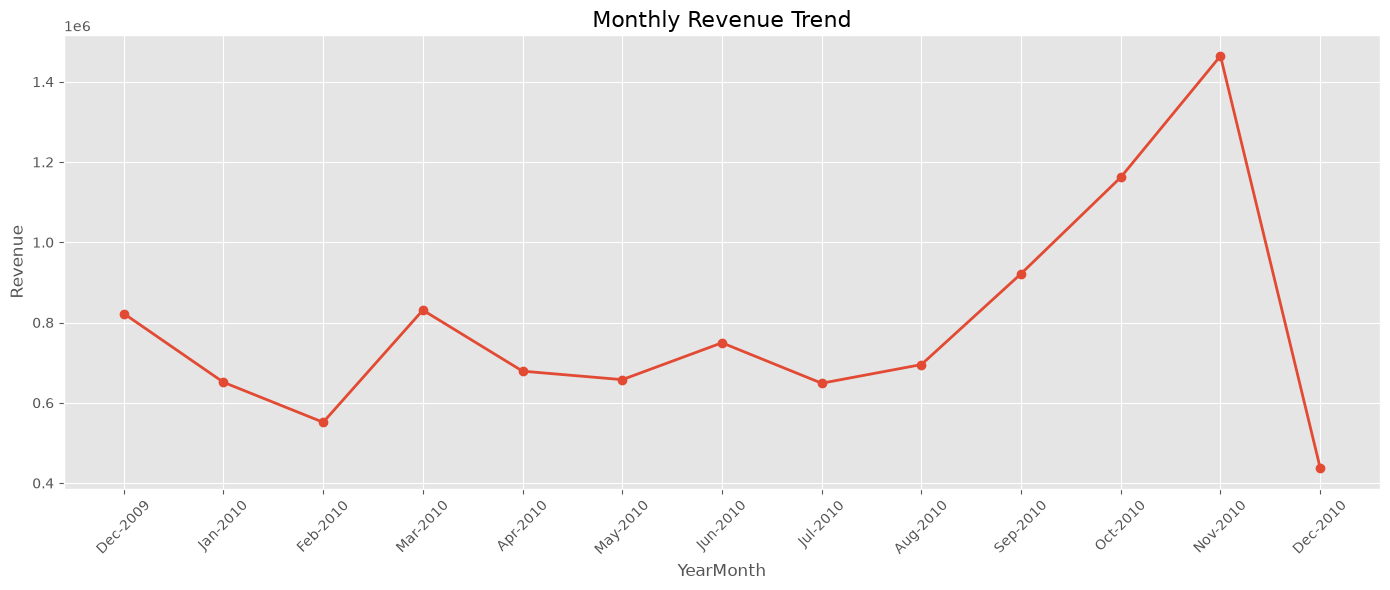

In [19]:
#Plot monthly revenue trend
plt.figure(figsize=(14,6))

plt.plot(monthly_revenue["YearMonth"],monthly_revenue["Revenue"],marker="o",linewidth=2)
plt.title("Monthly Revenue Trend",fontsize=16)
plt.xlabel("YearMonth")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [20]:
#Highest Revenue Month
highest_month = monthly_revenue.loc[monthly_revenue["Revenue"].idxmax()]
highest_month 

Year                2010
Month                 11
MonthName       November
Revenue      1464293.142
YearMonth       Nov-2010
Name: 11, dtype: object

In [21]:
print("=" * 50)
print("Highest Revenue YearMonth")
print("=" * 50)

print (f"Year: {highest_month['Year']}")
print (f"Month: {highest_month['MonthName']}")
print (f"Revenue: ${highest_month['Revenue']:,.2f}")

Highest Revenue YearMonth
Year: 2010
Month: November
Revenue: $1,464,293.14


In [22]:
#Lowest Month Revenue
lowest_month = monthly_revenue.loc[monthly_revenue["Revenue"].idxmin()]
print("=" * 50)
print("lowest Revenue YearMonth")
print("=" * 50)

print(f"Year: {lowest_month['Year']}")
print(f"Month: {lowest_month['MonthName']}")
print(f"Revenue: ${lowest_month['Revenue']:,.2f}")

lowest Revenue YearMonth
Year: 2010
Month: December
Revenue: $437,631.02


### Why is Monthly Revenue Important?

Monthly revenue analysis helps businesses:
- Identify seasonal demand
- Forecast future sales
- Allocate inventory efficiently
- Evaluate marketing campaigns
- Measure business growth

### Insight 1

Revenue remained relatively stable from December 2009 to August 2010, fluctuating between approximately $550K and $830K.

### Insight 2

A sharp increase in revenue begins in September 2010, indicating the start of the holiday shopping season.

### Insight 3

The highest monthly revenue was recorded in November 2010 ($1.46M), making it the strongest sales month.

### Insight 4

Revenue dropped significantly in December 2010 ($437K).

# Revenue by Country Analysis

In [23]:
country_revenue = (df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).reset_index())
country_revenue 

,Country,Revenue
0,United Kingdom,8812311.833
1,EIRE,380909.570
2,Netherlands,268784.350
3,Germany,202025.391
4,France,147103.140
5,Sweden,53501.990
6,Denmark,50906.850
7,Spain,47568.650
8,Switzerland,43921.390
9,Australia,31446.800


In [24]:
top10 = country_revenue.head(10)
top10

,Country,Revenue
0,United Kingdom,8812311.833
1,EIRE,380909.570
2,Netherlands,268784.350
3,Germany,202025.391
4,France,147103.140
5,Sweden,53501.990
6,Denmark,50906.850
7,Spain,47568.650
8,Switzerland,43921.390
9,Australia,31446.800


In [25]:
country_revenue["Contribution%"] = (country_revenue["Revenue"] / country_revenue["Revenue"].sum() * 100)

In [26]:
country_revenue.head()

,Country,Revenue,Contribution%
0,United Kingdom,8812311.833,85.791622
1,EIRE,380909.570,3.708317
2,Netherlands,268784.350,2.616731
3,Germany,202025.391,1.966804
4,France,147103.140,1.432112


In [27]:
print("="*50)
print("Top 10 Revenue Generating Countries")
print("="*50)

country_revenue.head(10)

Top 10 Revenue Generating Countries


,Country,Revenue,Contribution%
0,United Kingdom,8812311.833,85.791622
1,EIRE,380909.570,3.708317
2,Netherlands,268784.350,2.616731
3,Germany,202025.391,1.966804
4,France,147103.140,1.432112
5,Sweden,53501.990,0.520865
6,Denmark,50906.850,0.495600
7,Spain,47568.650,0.463101
8,Switzerland,43921.390,0.427594
9,Australia,31446.800,0.306148


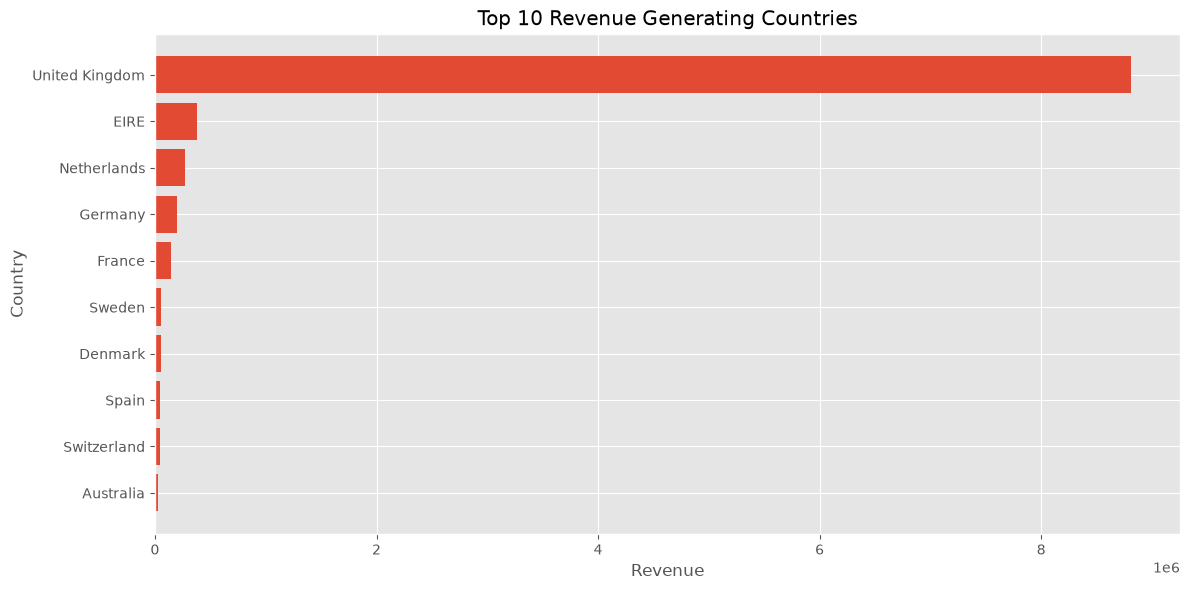

In [29]:
#Visualisation
plt.figure(figsize=(12,6))

plt.barh(top10["Country"],top10["Revenue"])

plt.title("Top 10 Revenue Generating Countries")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [30]:
#Highest Revenue Country
print("="*50)
print("Highest Revenue Country")
print("="*50)

country_revenue.head(1)

Highest Revenue Country


,Country,Revenue,Contribution%
0,United Kingdom,8812311.833,85.791622


In [32]:
print("="*50)
print("Lowest Revenue Country")
print("="*50)

country_revenue.tail(1)

Lowest Revenue Country


,Country,Revenue,Contribution%
39,Nigeria,140.39,0.001367


### Which countries contribute the highest revenue to the company, and how concentrated is the business across different markets?

### Insight 1

The United Kingdom generated approximately 85.79% of total revenue, making it the company's primary market.

### Insight 2

Countries such as EIRE, Netherlands, Germany, and France contribute significantly less revenue compared to the UK.

### Insight 3

Revenue is highly concentrated in a single country, indicating a lack of geographical diversification.

### Insight 4

Countries like Nigeria contribute almost no revenue, suggesting either a very small customer base or limited business operations.

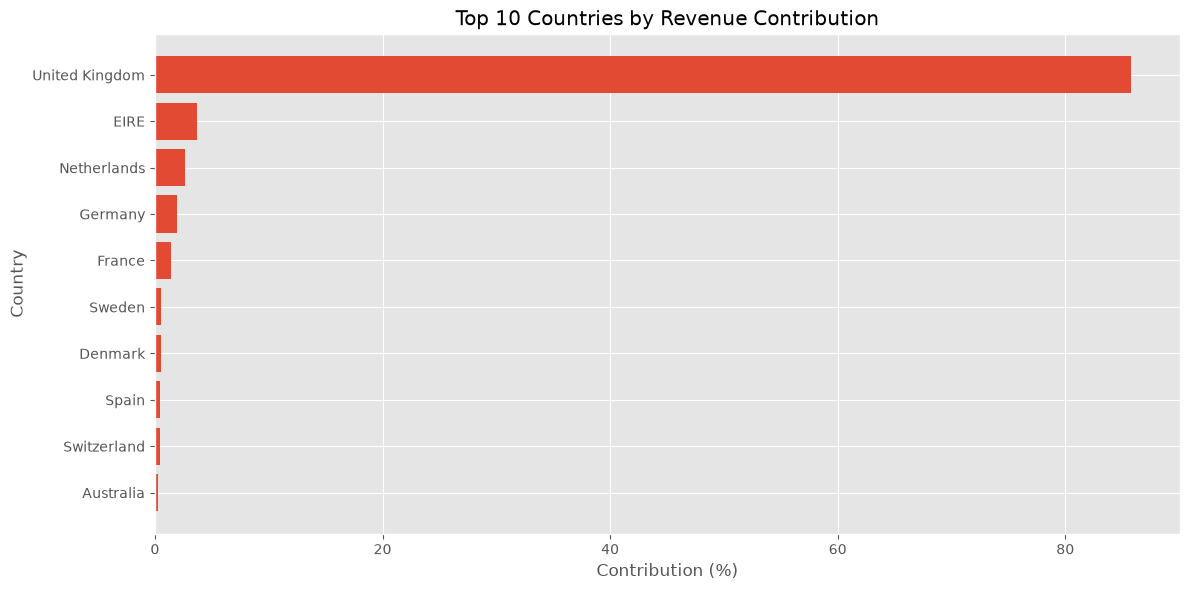

In [34]:
#Seconday visualisation based on contribution percentage

top10 = country_revenue.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10["Country"],
    top10["Contribution%"]
)

plt.title("Top 10 Countries by Revenue Contribution")

plt.xlabel("Contribution (%)")

plt.ylabel("Country")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

### Product Performance Analysis

Which products generate the highest revenue and contribute the most to overall business performance?

- Product-level analysis helps businesses:
- Identify best-selling products.
- Optimize inventory planning.
- Improve product assortment.
- Design marketing campaigns.
- Increase profitability.

In [35]:
#Revenue by Product

product_revenue = (df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).reset_index())
product_revenue.head()

,Description,Revenue
0,Manual,262589.86
1,REGENCY CAKESTAND 3 TIER,169912.76
2,WHITE HANGING HEART T-LIGHT HOLDER,160345.63
3,DOTCOM POSTAGE,116408.71
4,ASSORTED COLOUR BIRD ORNAMENT,72890.19


In [36]:
#Top 10 Revenue Products

top_products = product_revenue.head(10)
top_products

,Description,Revenue
0,Manual,262589.86
1,REGENCY CAKESTAND 3 TIER,169912.76
2,WHITE HANGING HEART T-LIGHT HOLDER,160345.63
3,DOTCOM POSTAGE,116408.71
4,ASSORTED COLOUR BIRD ORNAMENT,72890.19
5,PAPER CHAIN KIT 50'S CHRISTMAS,58127.30
6,JUMBO BAG RED RETROSPOT,56480.46
7,PARTY BUNTING,49664.12
8,POSTAGE,49477.54
9,ROTATING SILVER ANGELS T-LIGHT HLDR,47954.49


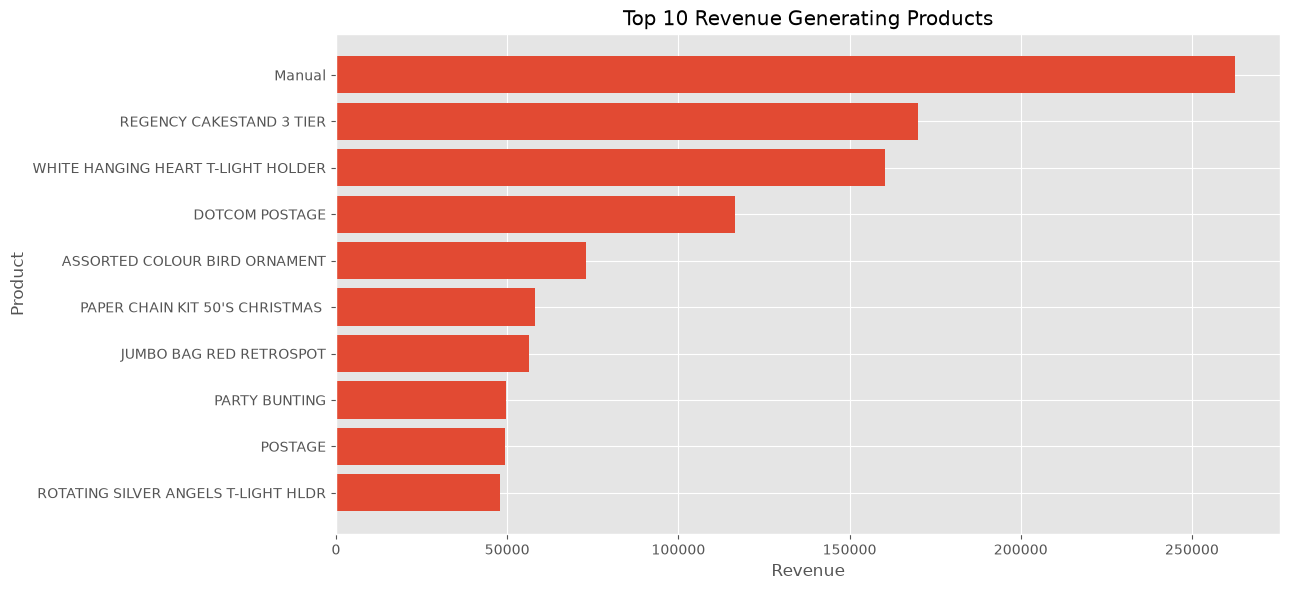

In [37]:
#Plot Revenue

plt.figure(figsize=(13,6))

plt.barh(top_products["Description"],top_products["Revenue"])
plt.title("Top 10 Revenue Generating Products")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [38]:
#Highest Revenue Product

print("="*50)
print("Highest Revenue Product")
print("="*50)

product_revenue.head(1)

Highest Revenue Product


,Description,Revenue
0,Manual,262589.86


In [39]:
#Revenue Contribution

product_revenue["Contribution (%)"] = (product_revenue["Revenue"]/ product_revenue["Revenue"].sum() * 100)
product_revenue.head(10)

,Description,Revenue,Contribution (%)
0,Manual,262589.86,2.556425
1,REGENCY CAKESTAND 3 TIER,169912.76,1.654173
2,WHITE HANGING HEART T-LIGHT HOLDER,160345.63,1.561033
3,DOTCOM POSTAGE,116408.71,1.133289
4,ASSORTED COLOUR BIRD ORNAMENT,72890.19,0.709617
5,PAPER CHAIN KIT 50'S CHRISTMAS,58127.30,0.565894
6,JUMBO BAG RED RETROSPOT,56480.46,0.549861
7,PARTY BUNTING,49664.12,0.483501
8,POSTAGE,49477.54,0.481685
9,ROTATING SILVER ANGELS T-LIGHT HLDR,47954.49,0.466857


In [40]:
#Top 10 Contributer

product_revenue.head(10)[["Description","Revenue","Contribution (%)"]]

,Description,Revenue,Contribution (%)
0,Manual,262589.86,2.556425
1,REGENCY CAKESTAND 3 TIER,169912.76,1.654173
2,WHITE HANGING HEART T-LIGHT HOLDER,160345.63,1.561033
3,DOTCOM POSTAGE,116408.71,1.133289
4,ASSORTED COLOUR BIRD ORNAMENT,72890.19,0.709617
5,PAPER CHAIN KIT 50'S CHRISTMAS,58127.30,0.565894
6,JUMBO BAG RED RETROSPOT,56480.46,0.549861
7,PARTY BUNTING,49664.12,0.483501
8,POSTAGE,49477.54,0.481685
9,ROTATING SILVER ANGELS T-LIGHT HLDR,47954.49,0.466857


In [41]:
#Quantity by Product

product_quantity = (df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).reset_index())
product_quantity.head(10)

,Description,Quantity
0,WHITE HANGING HEART T-LIGHT HOLDER,58691
1,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54947
2,BROCADE RING PURSE,48374
3,PACK OF 72 RETRO SPOT CAKE CASES,46728
4,ASSORTED COLOUR BIRD ORNAMENT,45228
5,60 TEATIME FAIRY CAKE CASES,36348
6,PACK OF 60 PINK PAISLEY CAKE CASES,31805
7,JUMBO BAG RED RETROSPOT,30746
8,SMALL POPCORN HOLDER,29773
9,STRAWBERRY CERAMIC TRINKET BOX,27059


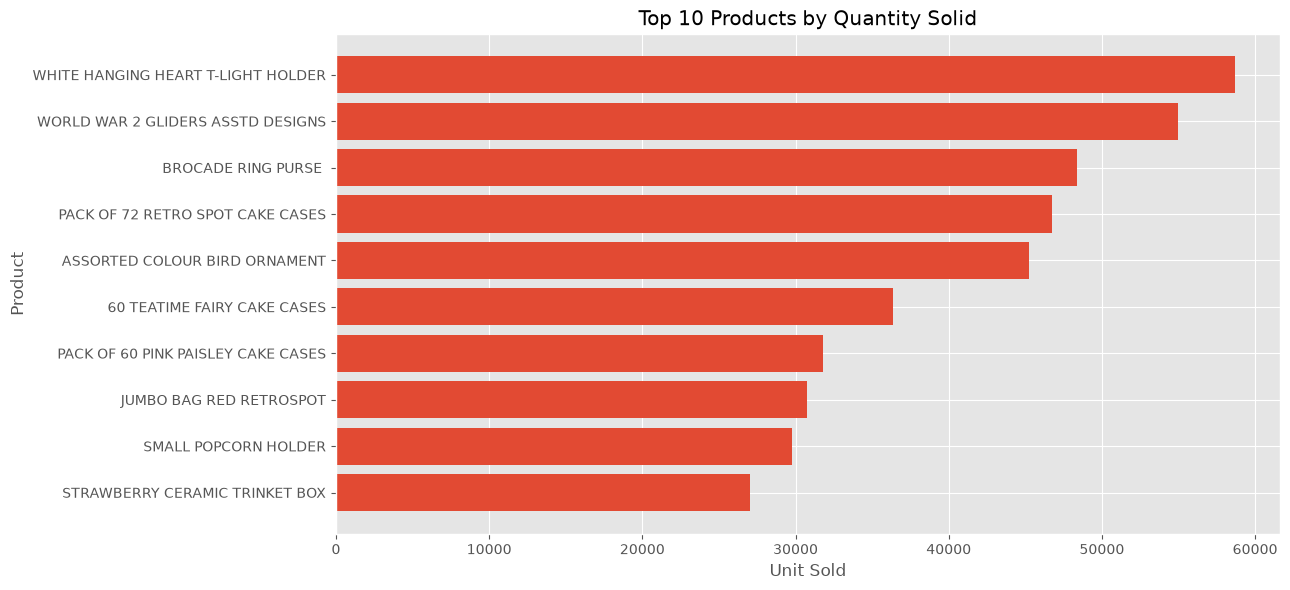

In [43]:
#Quantity Chart

plt.figure(figsize=(13,6))

plt.barh(product_quantity.head(10)["Description"],product_quantity.head(10)["Quantity"])
plt.title("Top 10 Products by Quantity Solid")
plt.xlabel("Unit Sold")
plt.ylabel("Product")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

There is an important difference between:

Highest Revenue Product

Earns the most money.

Highest Quantity Product

Sells the most units.

These are not always the same product.

A luxury item may generate high revenue with few sales, while a low-cost item may sell thousands of units but contribute less revenue.

### Customer Analysis

In [44]:
#Customer Revenue

customer_revenue = (df.groupby("Customer ID")["Revenue"].sum().sort_values(ascending=False))
customer_revenue.head(10)

Customer ID
18102.0    349164.35
14646.0    248396.50
14156.0    196549.74
14911.0    152121.22
13694.0    131443.19
17511.0     84541.17
15061.0     83284.38
16684.0     80489.21
16754.0     65500.07
17949.0     60117.60
Name: Revenue, dtype: float64

In [45]:
#Top 10 Customers

top_customers = customer_revenue.head(10).reset_index()
top_customers

,Customer ID,Revenue
0,18102.0,349164.35
1,14646.0,248396.50
2,14156.0,196549.74
3,14911.0,152121.22
4,13694.0,131443.19
5,17511.0,84541.17
6,15061.0,83284.38
7,16684.0,80489.21
8,16754.0,65500.07
9,17949.0,60117.60


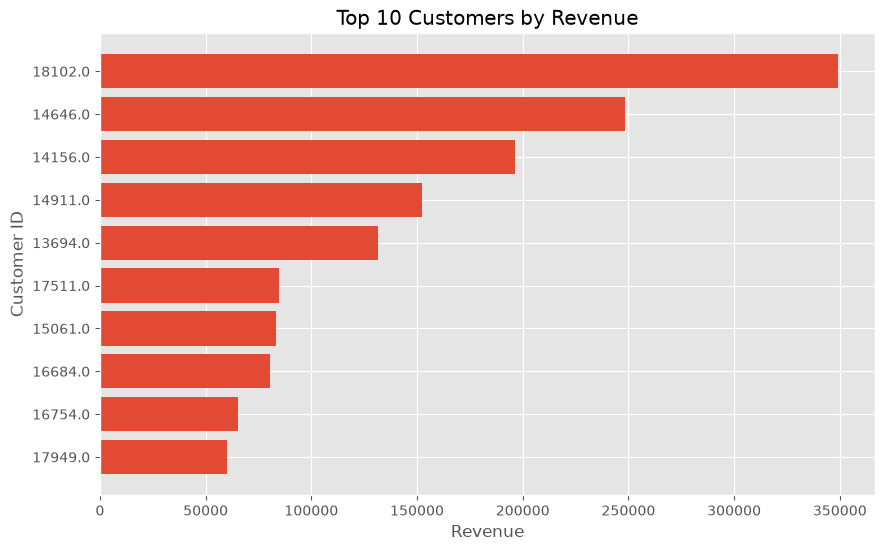

In [46]:
#Plot Top Customer

plt.figure(figsize=(10,6))

plt.barh(top_customers["Customer ID"].astype(str),top_customers["Revenue"])

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")
plt.gca().invert_yaxis()
plt.show()

In [47]:
#Revenue Contribution

top_customers["Contribution %"] = (top_customers["Revenue"] / df["Revenue"].sum()) * 100
top_customers

,Customer ID,Revenue,Contribution %
0,18102.0,349164.35,3.399264
1,14646.0,248396.50,2.418246
2,14156.0,196549.74,1.913496
3,14911.0,152121.22,1.480965
4,13694.0,131443.19,1.279656
5,17511.0,84541.17,0.823044
6,15061.0,83284.38,0.810809
7,16684.0,80489.21,0.783597
8,16754.0,65500.07,0.637671
9,17949.0,60117.60,0.585271


In [48]:
print("="*50)
print("Top Customer")
print("="*50)

print(top_customers.head(1))

print("\n")

print("="*50)
print("Top 10 Customers Contribution")
print("="*50)

print(round(top_customers["Contribution %"].sum(),2),"%")

Top Customer
   Customer ID    Revenue  Contribution %
0      18102.0  349164.35        3.399264


Top 10 Customers Contribution
14.13 %


In [49]:
# Top 10 Customers by Revenue

customer_revenue = (df.dropna(subset=["Customer ID"]).groupby("Customer ID")["Revenue"].sum().sort_values(ascending=False).head(10).reset_index())
customer_revenue

,Customer ID,Revenue
0,18102.0,349164.35
1,14646.0,248396.50
2,14156.0,196549.74
3,14911.0,152121.22
4,13694.0,131443.19
5,17511.0,84541.17
6,15061.0,83284.38
7,16684.0,80489.21
8,16754.0,65500.07
9,17949.0,60117.60


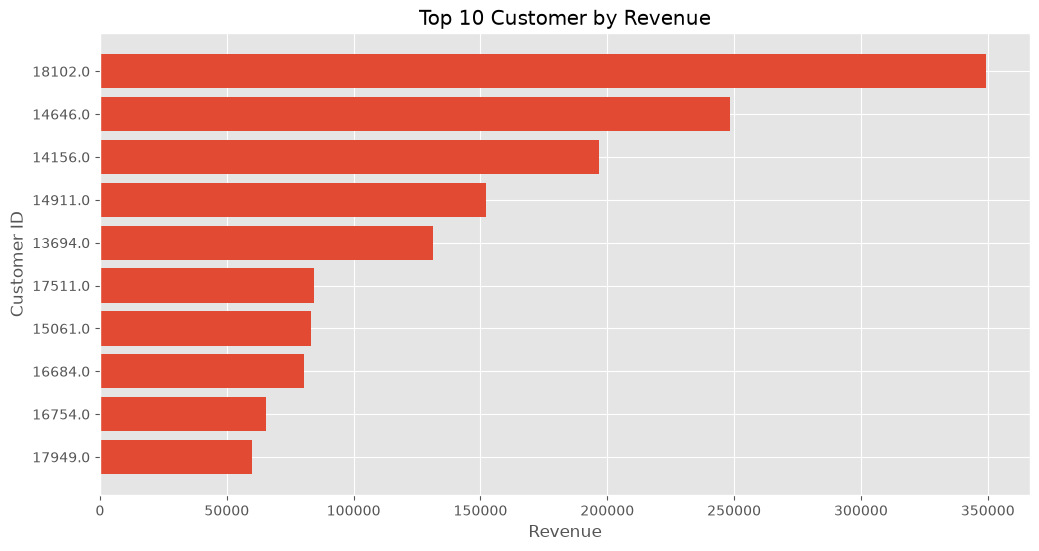

In [50]:
# Visualization

plt.figure(figsize=(12,6))
plt.barh(customer_revenue["Customer ID"].astype(str),customer_revenue["Revenue"])

plt.title("Top 10 Customer by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")

plt.gca().invert_yaxis()
plt.tight_layout
plt.show()

In [52]:
# Insights

print("="*50)
print("Top Revenue Customer")
print("="*50)

print(customer_revenue.head(1))

print("\n")
print("="*50)
print("Top 10 Customers Revenue")
print("="*50)
print(customer_revenue)

Top Revenue Customer
   Customer ID    Revenue
0      18102.0  349164.35


Top 10 Customers Revenue
   Customer ID    Revenue
0      18102.0  349164.35
1      14646.0  248396.50
2      14156.0  196549.74
3      14911.0  152121.22
4      13694.0  131443.19
5      17511.0   84541.17
6      15061.0   83284.38
7      16684.0   80489.21
8      16754.0   65500.07
9      17949.0   60117.60


In [53]:
# Customer Order Frequency

customer_orders = (df.dropna(subset=["Customer ID"]).groupby("Customer ID")["Invoice"].nunique().sort_values(ascending=False).head(10).reset_index(name="Orders"))
customer_orders

,Customer ID,Orders
0,14911.0,205
1,17850.0,155
2,12748.0,144
3,15311.0,121
4,13089.0,109
5,14606.0,102
6,14156.0,102
7,13694.0,94
8,17841.0,91
9,18102.0,89


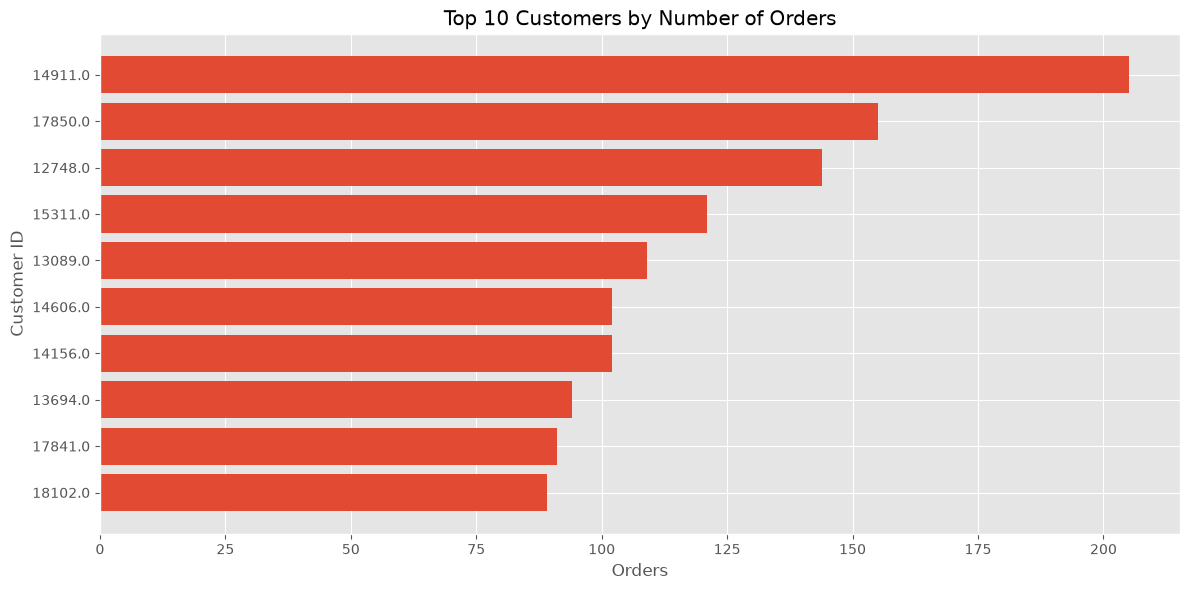

In [54]:
# Visualization of customer orderds

plt.figure(figsize=(12,6))

plt.barh(customer_orders["Customer ID"].astype(str),customer_orders["Orders"])

plt.title("Top 10 Customers by Number of Orders")
plt.xlabel("Orders")
plt.ylabel("Customer ID")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [55]:
# Insights

print("="*50)
print("Most Frequent Customers")
print("="*50)
print(customer_orders)

Most Frequent Customers
   Customer ID  Orders
0      14911.0     205
1      17850.0     155
2      12748.0     144
3      15311.0     121
4      13089.0     109
5      14606.0     102
6      14156.0     102
7      13694.0      94
8      17841.0      91
9      18102.0      89


### Daily Revenue Trend

In [57]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [58]:
#Daily Revenue
daily_revenue = (df.groupby(df["InvoiceDate"].dt.date)["Revenue"].sum().reset_index())

daily_revenue.columns = ["Date","Revenue"]
daily_revenue.head()

,Date,Revenue
0,2009-12-01,54351.23
1,2009-12-02,63172.58
2,2009-12-03,73972.45
3,2009-12-04,40582.32
4,2009-12-05,9803.05


In [60]:
#Highest & Lowest Revenue Days

highest_day = daily_revenue.loc[daily_revenue["Revenue"].idxmax()]
lowest_day = daily_revenue.loc[daily_revenue["Revenue"].idxmin()]

print("="*50)
print("Highest Revenue Day")
print("="*50)
print(highest_day)

print("\n")

print("="*50)
print("Lowest Revenue Day")
print("="*50)
print(lowest_day)

Highest Revenue Day
Date       2010-09-27
Revenue     118838.47
Name: 243, dtype: object


Lowest Revenue Day
Date       2010-07-11
Revenue       7784.95
Name: 177, dtype: object


### Weekday Sales Analysis

In [61]:
df["Weekday"] = df["InvoiceDate"].dt.day_name()

In [62]:
# Revenue by Weekday

weekday_sales = (df.groupby("Weekday")["Revenue"].sum().reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]).reset_index())
weekday_sales

,Weekday,Revenue
0,Monday,1860436.255
1,Tuesday,2002003.301
2,Wednesday,1745382.103
3,Thursday,2097097.802
4,Friday,1533319.022
5,Saturday,9803.050
6,Sunday,1023721.131


In [65]:
# Insights

highest = weekday_sales.loc[weekday_sales["Revenue"].idxmax()]
lowest = weekday_sales.loc[weekday_sales["Revenue"].idxmin()]

print("="*50)
print("Best Sales Day")
print("="*50)
print(highest)

print("\n")

print("="*50)
print("Lowest Sales Day")
print("="*50)
print(lowest)

Best Sales Day
Weekday       Thursday
Revenue    2097097.802
Name: 3, dtype: object


Lowest Sales Day
Weekday    Saturday
Revenue     9803.05
Name: 5, dtype: object


### Hourly Sales Pattern

In [66]:
df["Hour"] = df["InvoiceDate"].dt.hour

In [67]:
# Revenue by Hour

hourly_sales = (df.groupby("Hour")["Revenue"].sum().reset_index())
hourly_sales

,Hour,Revenue
0,7,45173.360
1,8,248566.860
2,9,811807.660
3,10,1180711.352
4,11,1339629.933
5,12,1459647.691
6,13,1330157.834
7,14,1199013.910
8,15,1121576.882
9,16,884153.701


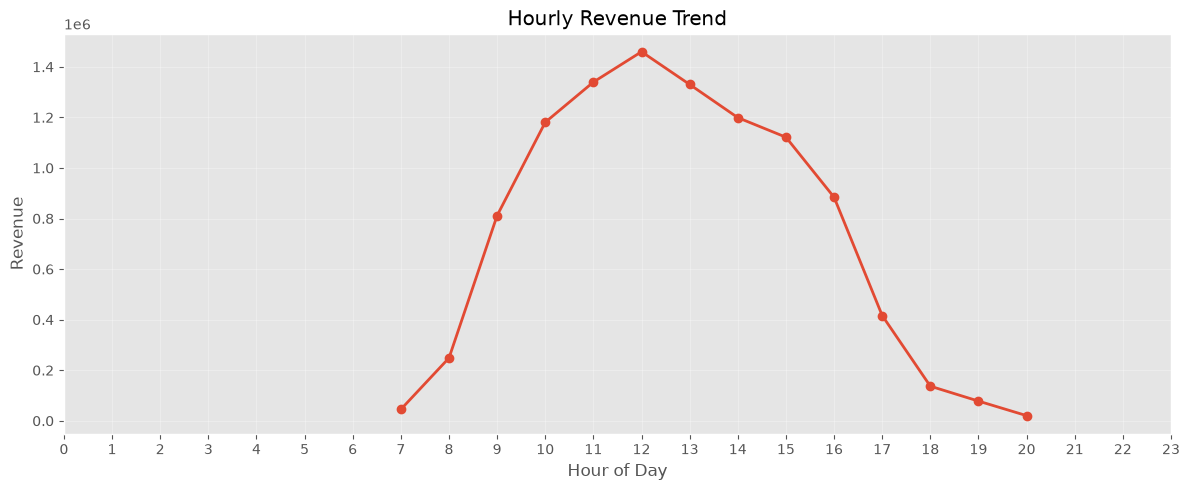

In [70]:
#Plot Hourly Sales

plt.figure(figsize=(12,5))

plt.plot(hourly_sales["Hour"],
         hourly_sales["Revenue"],
         marker="o",
         linewidth = 2)

plt.title("Hourly Revenue Trend")
plt.xlabel("Hour of Day")
plt.ylabel("Revenue")

plt.xticks(range(24))

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [72]:
#Orders by Hour
hourly_orders = (
    df.groupby("Hour")["Invoice"]
    .nunique()
    .reset_index(name="Orders")
)
hourly_orders


,Hour,Orders
0,7,50
1,8,452
2,9,1327
3,10,2347
4,11,2594
5,12,3341
6,13,3053
7,14,2704
8,15,2354
9,16,1449


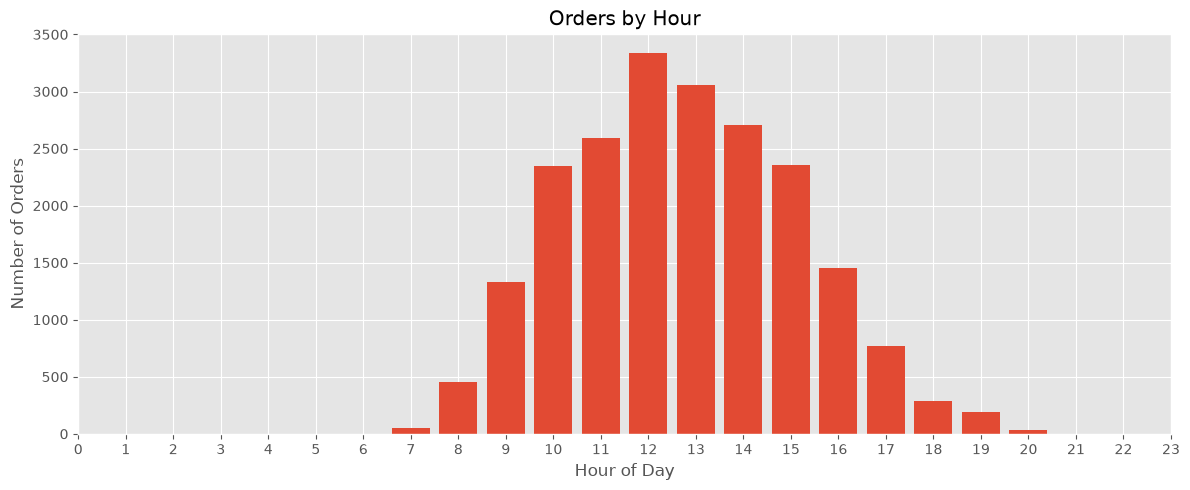

In [74]:
#PLot Orders

plt.figure(figsize=(12,5))

plt.bar(
    hourly_orders["Hour"],
    hourly_orders["Orders"]
)

plt.title("Orders by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")

plt.xticks(range(24))
plt.tight_layout()
plt.show()

In [76]:
#Insights

peak_revenue = hourly_sales.loc[hourly_sales["Revenue"].idxmax()]
lowest_revenue = hourly_sales.loc[hourly_sales["Revenue"].idxmin()]

peak_orders = hourly_orders.loc[hourly_orders["Orders"].idxmax()]

print("=" * 50)
print("Peak Revenue Hour")
print("=" * 50)
print(peak_revenue)

print("\n")

print("=" * 50)
print("Lowest Revenue Hour")
print("=" * 50)
print(lowest_revenue)

print("\n")

print("=" * 50)
print("Peak Order Hour")
print("=" * 50)
print(peak_orders)

Peak Revenue Hour
Hour            12.000
Revenue    1459647.691
Name: 5, dtype: float64


Lowest Revenue Hour
Hour          20.00
Revenue    20372.35
Name: 13, dtype: float64


Peak Order Hour
Hour        12
Orders    3341
Name: 5, dtype: int64


### Average Orders Value by Month

In [79]:
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

In [80]:
monthly_orders = (
    df.groupby("YearMonth")
    .agg(
        Revenue = ("Revenue","sum"),
        Orders = ("Invoice","nunique")
    )
    .reset_index()
)

monthly_orders["AverageOrderValue"] = (
    monthly_orders["Revenue"] /
    monthly_orders["Orders"]
)

monthly_orders

,YearMonth,Revenue,Orders,AverageOrderValue
0,2009-12,822483.950,1682,488.991647
1,2010-01,651155.112,1105,589.280644
2,2010-02,551504.726,1201,459.204601
3,2010-03,830915.261,1681,494.298192
4,2010-04,678875.252,1462,464.346958
5,2010-05,657705.500,1500,438.470333
6,2010-06,749537.310,1645,455.645781
7,2010-07,648810.270,1529,424.336344
8,2010-08,695251.910,1425,487.896077
9,2010-09,921696.991,1839,501.194666


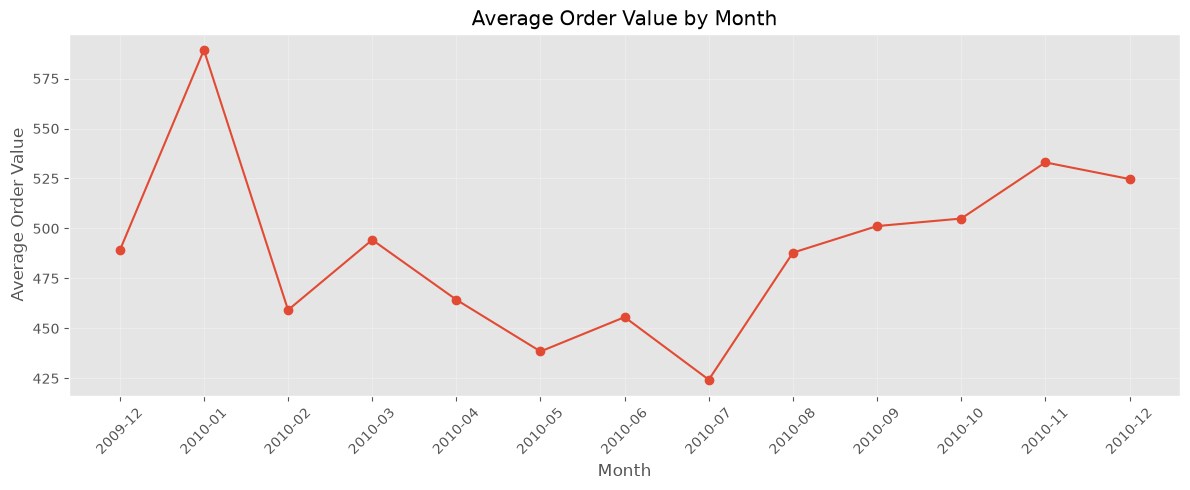

In [81]:
#Plot Average Order value By Month

plt.figure(figsize=(12,5))
plt.plot(
    monthly_orders["YearMonth"].astype(str),
    monthly_orders["AverageOrderValue"],
    marker="o"
)

plt.title("Average Order Value by Month")
plt.xlabel("Month")
plt.ylabel("Average Order Value")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [82]:
#Insights

highest_aov = monthly_orders.loc[
    monthly_orders["AverageOrderValue"].idxmax()
]

lowest_aov = monthly_orders.loc[
    monthly_orders["AverageOrderValue"].idxmin()
]

print("=" * 50)
print("Highest Average Order Value")
print("=" * 50)
print(highest_aov)

print("\n")

print("=" * 50)
print("Lowest Average Order Value")
print("=" * 50)
print(lowest_aov)

Highest Average Order Value
YearMonth               2010-01
Revenue              651155.112
Orders                     1105
AverageOrderValue    589.280644
Name: 1, dtype: object


Lowest Average Order Value
YearMonth               2010-07
Revenue               648810.27
Orders                     1529
AverageOrderValue    424.336344
Name: 7, dtype: object
